In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import trimesh

In [2]:
df = pd.read_pickle('./data.pkl')

In [3]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500

# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000

In [4]:
# Plot settings
colorTot = 'C0'; colorP = 'C1'; colorNP = 'C2'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .2)
nbinsTPC = np.arange(0, 1.61, .2)

In [5]:
# Front face normalization
norm_areas = np.array([])
r1 = 1.26  # m
r2 = 2.0   # m
r3 = 2.74  # m
for i in range(len(nbinsTPC)-1):
    radius = (beamCenterZ/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), 1.26, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), 2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), 1.26, np.sqrt(radius**2 - 4))[0]
        if radius > r3:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), 2.74, radius)[0]
        if radius > np.sqrt(r3**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - 2), 2.74, np.sqrt(radius**2 - 4))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas = np.append(norm_areas, np.abs(area))
norm_areas

array([0.46318395, 1.38959699, 2.31614549, 2.91337013, 3.17304591,
       2.64577569, 1.79511938, 1.07684058])

In [6]:
# Back face normalization
norm_areas_back = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ-tpcMinZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), 1.26, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), 2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), 1.26, np.sqrt(radius**2 - 4))[0]
        if radius > r3:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), 2.74, radius)[0]
        if radius > np.sqrt(r3**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - 2), 2.74, np.sqrt(radius**2 - 4))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas_back = np.append(norm_areas_back, np.abs(area))
norm_areas_back

array([0.50624857, 1.56185968, 2.70375229, 3.46214343, 3.94690699,
       3.15426951, 2.28352461, 1.23375337])

In [7]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[4, 4, 5])
tpcBox.apply_translation([0, 0, 2.5])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = 115 * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=115)
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([ 2.40724613,  7.22197472, 12.03740189, 16.85401715, 21.671929  ,
       14.81727631,  4.82415596,  0.16597083])

12276


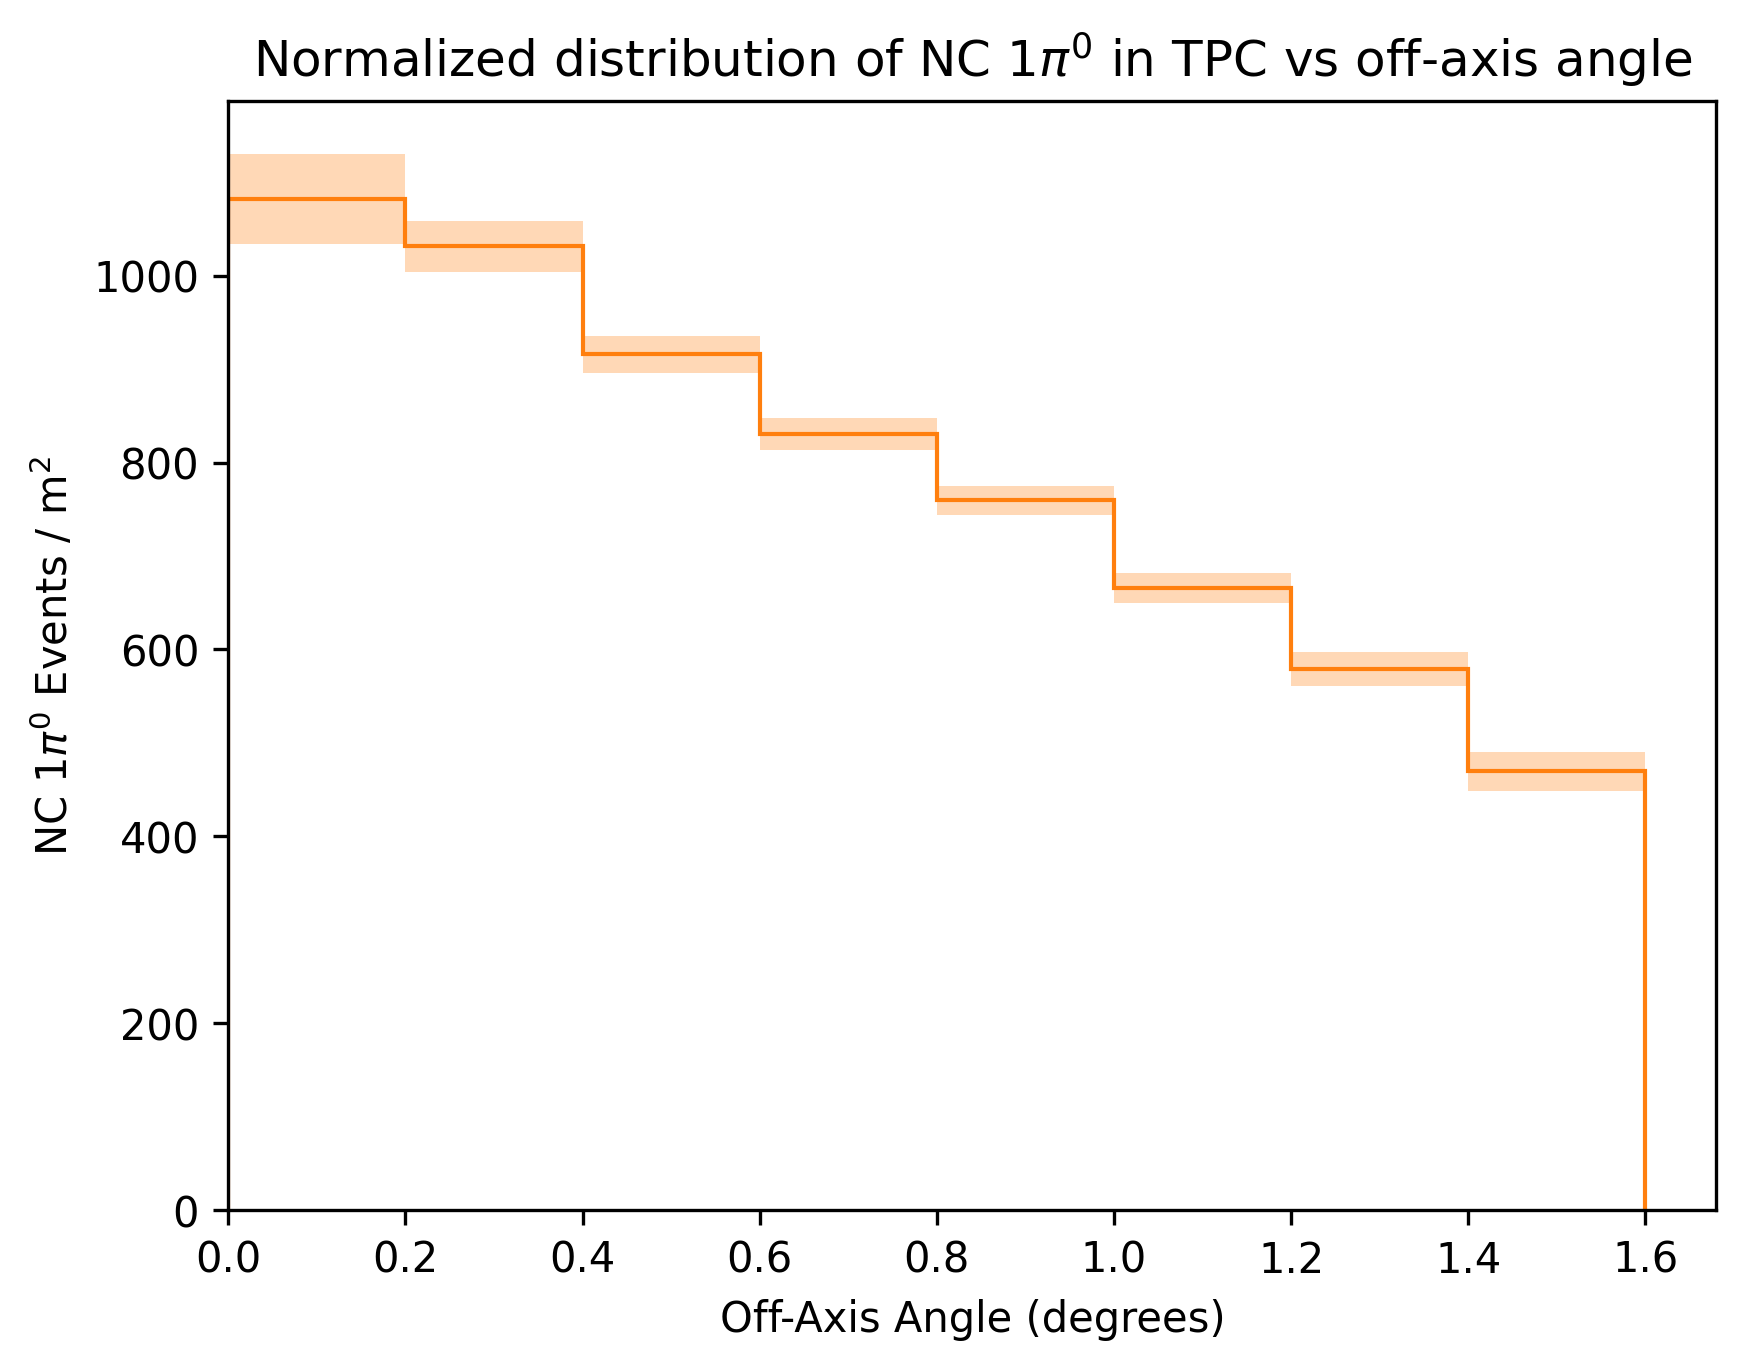

In [9]:
pi0_angles_tot = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_front']) > 0:
        if row['in_TPC_g4'][0]:
            pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_front'][0])
print(len(pi0_angles_tot))

plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorP)
plt.title(r'Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel(r'NC $1\pi^0$ Events / m$^2$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.show()